In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
fraud_df = pd.read_csv('/content/drive/MyDrive/Fraud detection DW&BI/PS_20174392719_1491204439457_log.csv')
fraud_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
fraud_df.shape

(6362620, 11)

In [7]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
#handle missing values
fraud_df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [9]:
#fraud count
fraud_df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


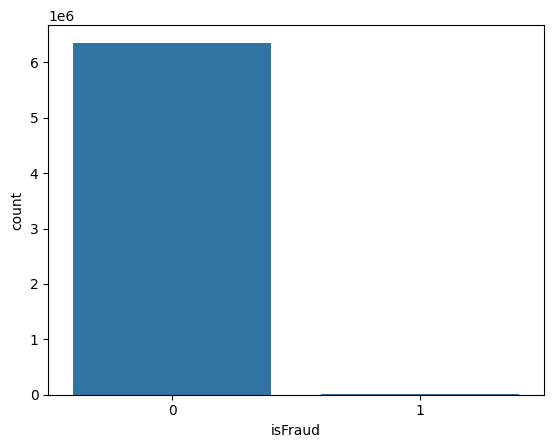

In [10]:
#fraud graph
sns.countplot(x='isFraud', data=fraud_df)
plt.show()

**DATA** **Preprocessing**

In [11]:
#remov unnec col
fraud_df = fraud_df.drop(['nameOrig', 'nameDest'], axis=1)

In [12]:
fraud_df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [13]:
#check transaction type
fraud_df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


**Convert Categories into Numbers**

*ML text nahi samajhta.*

Isliye encoding karenge. *italicized text*

In [14]:
fraud_df = pd.get_dummies(fraud_df, columns=['type'])

In [15]:
fraud_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,False,True,False


**Features & Target Separate**
X = inputs
y = output

In [16]:
X = fraud_df.drop('isFraud', axis=1)

y = fraud_df['isFraud']

In [17]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**ML Model**: Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=-1,
                       random_state=42)

In [21]:
#Predictions
y_pred = model.predict(X_test)

In [22]:
#accuracy check
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9996314411358843


In [23]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1270901       3]
 [    466    1154]]


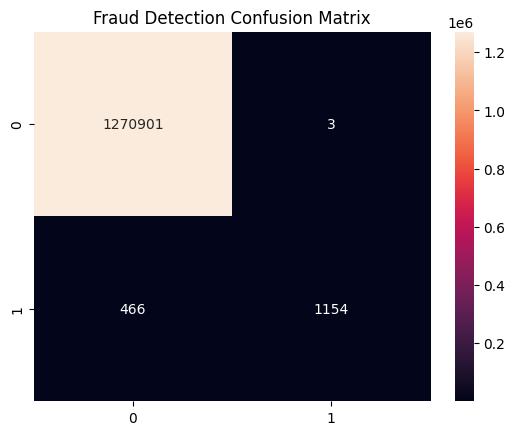

In [24]:
#Visualization
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Fraud Detection Confusion Matrix")

plt.show()

**FRAUD Analysis**

In [25]:
#Fraud by Transaction Type
fraud_by_type = fraud_df.groupby('type_TRANSFER')['isFraud'].sum()

print(fraud_by_type)

type_TRANSFER
False    4116
True     4097
Name: isFraud, dtype: int64


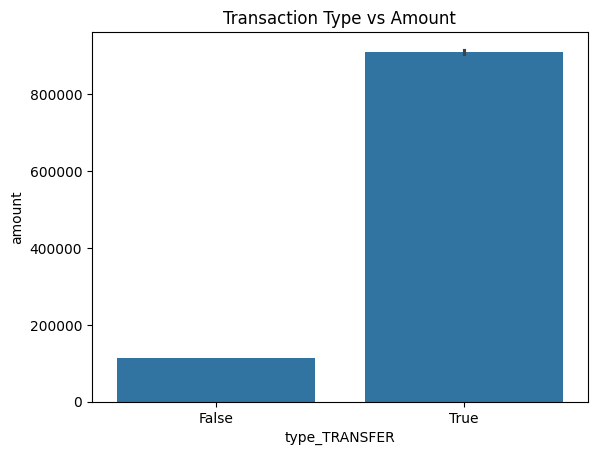

In [26]:
sns.barplot(
    x=fraud_df['type_TRANSFER'],
    y=fraud_df['amount']
)

plt.title("Transaction Type vs Amount")

plt.show()

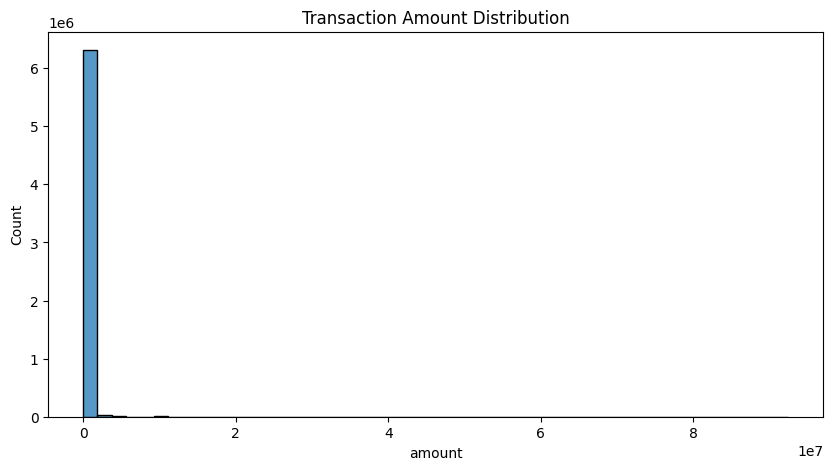

In [27]:
#Fraud Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    fraud_df['amount'],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

**Corelation Heatmap**

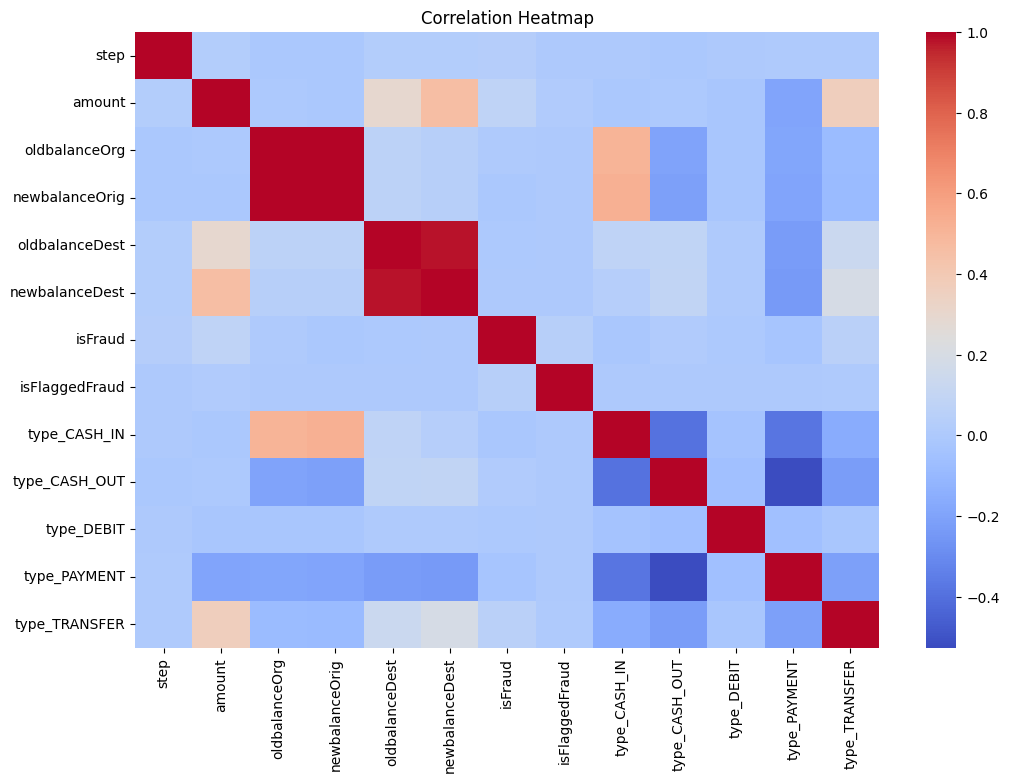

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    fraud_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Feature Importance**

Ab model batayega:
sabse important fraud indicators kya hain.

In [29]:
importance = model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df.head(10))

           Feature  Importance
5   newbalanceDest    0.294043
2    oldbalanceOrg    0.256173
1           amount    0.123646
11   type_TRANSFER    0.097689
0             step    0.077678
3   newbalanceOrig    0.060331
4   oldbalanceDest    0.059072
8    type_CASH_OUT    0.025054
7     type_CASH_IN    0.002967
10    type_PAYMENT    0.002476


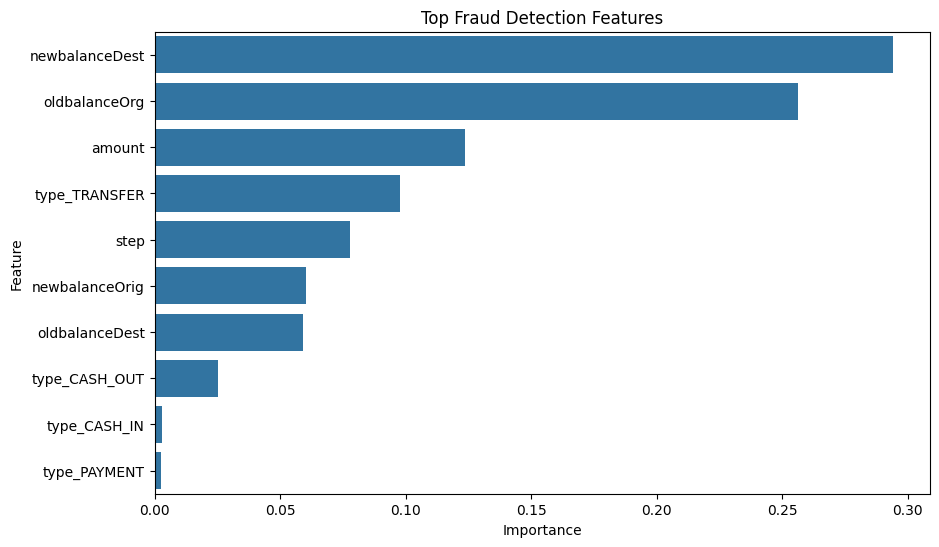

In [30]:
#Feature Importance Graph
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df.head(10)
)

plt.title("Top Fraud Detection Features")

plt.show()

C** **bold text**lassification Report**

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       1.00      0.71      0.83      1620

    accuracy                           1.00   1272524
   macro avg       1.00      0.86      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



**Save Clean Dataset**
Yeh Power BI aur SQL phase me use hoga.

In [32]:
fraud_df.to_csv(
    'cleaned_fraud_data.csv',
    index=False
)